In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
curr_dir_path = os.getcwd()
main_dir_path = os.path.abspath(os.path.join(curr_dir_path, os.pardir))
data_dir_path = os.path.join(main_dir_path, 'data')
raw_data_dir_path = os.path.join(data_dir_path, 'raw_data')
emissions_data_dir_path = os.path.join(raw_data_dir_path, 'emissions_data')
iea_data_dir_path = os.path.join(raw_data_dir_path, 'IEA_climate_policy_data')

In [4]:
IEA_policies_df = pd.read_csv(os.path.join(iea_data_dir_path, 'IEA_PAMS_Export 1_29_2025, 6_11_31 PM.csv'))
IEA_policies_df.head()

,year,jurisdiction,title,description,status,ISO3,country,topic,type,category,source
0,2011.0,National,Law 47-09 on Energy Efficiency,"Law 47-09, or the ""Law on Energy Efficiency"" a...",In force,MAR,Morocco,NaN,NaN,NaN,http://www.muat.gov.ma/sites/default/files/Reg...
1,2017.0,National,Swiss Energy Strategy 2050,Swiss Energy Strategy 2050The Swiss Energy Str...,In force,CHE,Switzerland,Economy-wide,"Master Energy Plan,Framework legislation",NaN,https://www.uvek.admin.ch/uvek/de/home/energie...
2,2009.0,National,Buy Smart project,"The aim of the Buy Smart""- project is to promo...",Ended,DEU,Germany,NaN,NaN,NaN,https://www.european-energy-award.de/european-...
3,2010.0,National,A Group of Energy Efficiency Measures in Agric...,This group consists of five PAMs.1. Biomass bo...,In force,FIN,Finland,NaN,NaN,NaN,http://www.mmm.fi/en/index/frontpage.html
4,1999.0,National,New Buses,Financial assistance to regions and municipali...,In force,ITA,Italy,NaN,NaN,NaN,NaN


In [5]:
# Make all col names lowercase
IEA_policies_df.columns = IEA_policies_df.columns.str.lower()

# drop source column
IEA_policies_df = IEA_policies_df.drop(columns=['source'])

## Data Integrity and Initial Cleaning

### Missing data in important columns
- year.
- iso3.

In [6]:
IEA_policies_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13155 entries, 0 to 13154
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   year          13127 non-null  float64
 1   jurisdiction  13155 non-null  object 
 2   title         13155 non-null  object 
 3   description   13119 non-null  object 
 4   status        13155 non-null  object 
 5   iso3          13149 non-null  object 
 6   country       13155 non-null  object 
 7   topic         7046 non-null   object 
 8   type          7046 non-null   object 
 9   category      3630 non-null   object 
dtypes: float64(1), object(9)
memory usage: 1.0+ MB


In [7]:
# Check for duplicates
duplicates = IEA_policies_df.duplicated(keep='first')
duplicates.value_counts()

False    12739
True       416
Name: count, dtype: int64

In [8]:
# Eliminate duplicates
IEA_policies_df = IEA_policies_df.drop_duplicates()

In [9]:
# Check for NaN in year column
IEA_policies_df['year'].isnull().value_counts()

year
False    12712
True        27
Name: count, dtype: int64

In [10]:
# Print null cols where year is null
# IEA_policies_df[IEA_policies_df['year'].isnull()]

In [11]:
# For now let's drop the rows with NaN in year column
IEA_policies_df = IEA_policies_df.dropna(subset=['year'])

In [12]:
# set year column to integer
IEA_policies_df['year'] = IEA_policies_df['year'].astype(int)

In [13]:
# Check for NaN in iso3 column
IEA_policies_df['iso3'].isnull().value_counts()

iso3
False    12707
True         5
Name: count, dtype: int64

In [14]:
# Check the records with missing iso3
IEA_policies_df[IEA_policies_df['iso3'].isnull()]

,year,jurisdiction,title,description,status,iso3,country,topic,type,category
226,2013,International,Climate Technology Centre and Network Technica...,The Climate Technology Centre and Network (CTC...,In force,NaN,Unknown,NaN,NaN,NaN
229,2009,International,The World Bank Carbon Capture and Storage Capa...,"The World Bank CCS Trust Fund, established in ...",In force,NaN,Unknown,NaN,NaN,NaN
3325,2015,International,The Vatican’s Laudato Si’ Action Platform,Pope Francis issued the Laudato Si’ encyclical...,In force,NaN,Vatican City,People-Centred Clean Energy Transitions,"Socioeconomic development,,Public participation,",NaN
3342,2008,National,Vatican installation of PV system,"To help green its operations, as promoted by P...",In force,NaN,Vatican City,People-Centred Clean Energy Transitions,"Energy security and resilience,,Public partici...",NaN
5019,2019,International,LEAP-RE,LEAP-RE is a mechanism for funding R&amp;D and...,In force,NaN,African Union,Technology R&D and innovation,"Grants,Resource push",Grants for R&D projects


In [15]:
# Drop rows with NaN in iso3 column
IEA_policies_df = IEA_policies_df.dropna(subset=['iso3'])

In [16]:
# Check jurisdiction column
IEA_policies_df['jurisdiction'].unique()

array(['National', 'City/Municipal', 'State/Provincial', 'International',
       'Unknown', 'Other', 'Regional', 'National '], dtype=object)

In [17]:
# Replace the 'National ' values to 'National' in the jurisdiction column
IEA_policies_df.loc[IEA_policies_df['jurisdiction'] == 'National ', 'jurisdiction'] = 'National'

In [18]:
IEA_policies_df['jurisdiction'].unique()

array(['National', 'City/Municipal', 'State/Provincial', 'International',
       'Unknown', 'Other', 'Regional'], dtype=object)

In [19]:
# Filter the years to match the emissions data
IEA_policies_df = IEA_policies_df[(IEA_policies_df['year'] >= 2000) & (IEA_policies_df['year'] <= 2022)]

In [20]:
IEA_policies_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9596 entries, 0 to 13154
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   year          9596 non-null   int64 
 1   jurisdiction  9596 non-null   object
 2   title         9596 non-null   object
 3   description   9570 non-null   object
 4   status        9596 non-null   object
 5   iso3          9596 non-null   object
 6   country       9596 non-null   object
 7   topic         4289 non-null   object
 8   type          4289 non-null   object
 9   category      2388 non-null   object
dtypes: int64(1), object(9)
memory usage: 824.7+ KB


In [21]:
# Fill NaNs with Unknown
IEA_policies_df = IEA_policies_df.fillna('Unknown')

## Understanding the Data

- Num of regions: 217


In [22]:
# How many countries we have?
IEA_policies_df['country'].unique()

array(['Morocco', 'Switzerland', 'Germany', 'Finland', 'Greece',
       'Netherlands', "People's Republic of China", 'Turkiye', 'France',
       'United States', 'New Zealand', 'Canada', 'Norway', 'Spain',
       'Luxembourg', 'Sweden', 'Australia', 'Italy',
       'United Arab Emirates', 'United Kingdom', 'Portugal', 'Tunisia',
       'Korea', 'Hungary', 'Japan', 'Russian Federation',
       'European Union', 'Turkmenistan', 'Singapore', 'India',
       'Lithuania', 'Poland', 'Denmark', 'Mexico', 'Brazil', 'Viet Nam',
       'Bolivarian Republic of Venezuela', 'Argentina', 'Israel',
       'Ukraine', 'Costa Rica', 'Peru', 'Jordan', 'Malaysia', 'Uruguay',
       'Saudi Arabia', 'Ghana', 'Pakistan', 'Belarus', 'Panama',
       'Tajikistan', 'Armenia', 'Barbados', 'Kenya', 'Nigeria', 'Iceland',
       'Mauritius', 'Zimbabwe', 'Azerbaijan', 'Philippines', 'Angola',
       'Ethiopia', 'Namibia', 'Jamaica', 'Afghanistan', 'Bahrain',
       'Benin', 'Bangladesh', 'Bhutan', 'Algeria',
       

In [23]:
# Print the amount of countries
len(IEA_policies_df['country'].unique())

215

In [24]:
# How many policies each country has?
policies_per_country_df = IEA_policies_df['country'].value_counts().reset_index()
policies_per_country_df.columns = ['country', 'policy_count']
policies_per_country_df



,country,policy_count
0,United States,624
1,Australia,383
2,Canada,371
3,People's Republic of China,349
4,United Kingdom,312
...,...,...
210,French Polynesia,1
211,British Indian Ocean Territory,1
212,Netherlands Antilles,1
213,State of Palestine,1


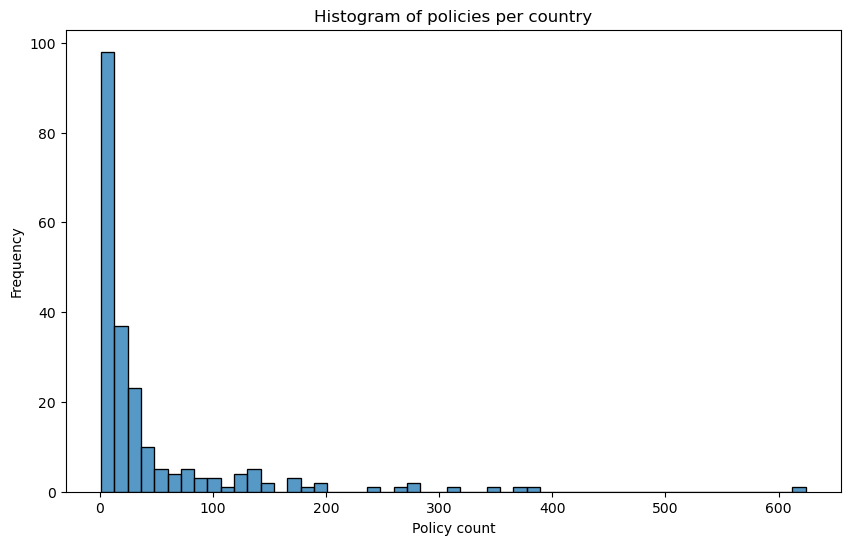

In [25]:
# Histogram of policies per country
plt.figure(figsize=(10, 6))
sns.histplot(policies_per_country_df['policy_count'])
plt.title('Histogram of policies per country')
plt.xlabel('Policy count')
plt.ylabel('Frequency')
plt.show()


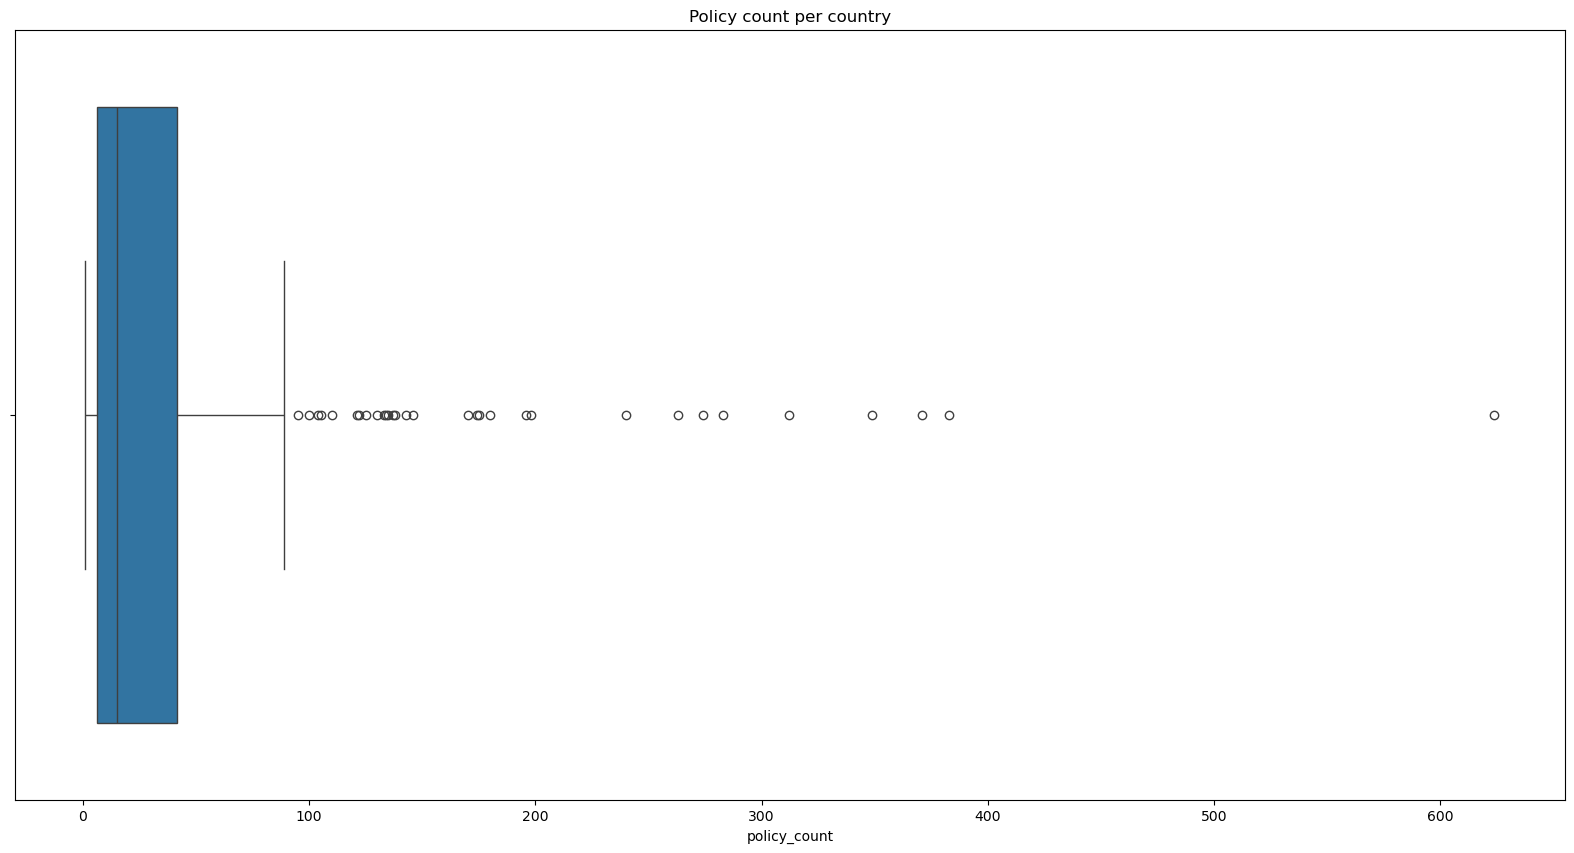

In [26]:
# Boxplot of policy count per country
plt.figure(figsize=(20, 10))
sns.boxplot(data=policies_per_country_df, x='policy_count')
plt.title('Policy count per country')
plt.show()

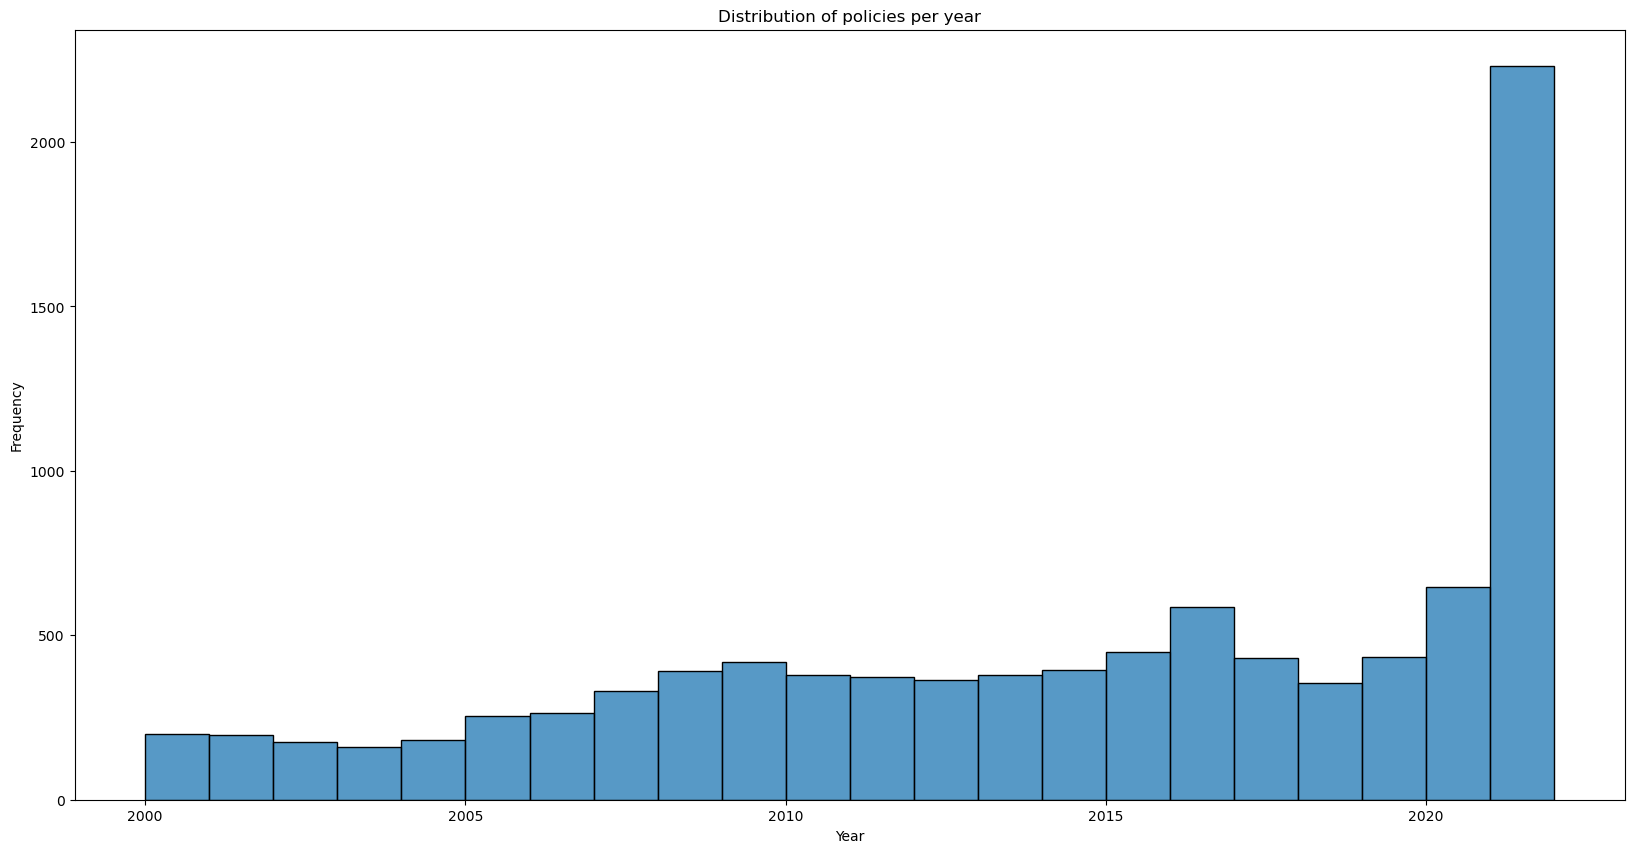

In [27]:
# Check the distribution of policies per year
plt.figure(figsize=(20, 10))
sns.histplot(IEA_policies_df['year'])
plt.title('Distribution of policies per year')
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.show()

In [28]:
IEA_policies_df.columns

Index(['year', 'jurisdiction', 'title', 'description', 'status', 'iso3',
       'country', 'topic', 'type', 'category'],
      dtype='object')

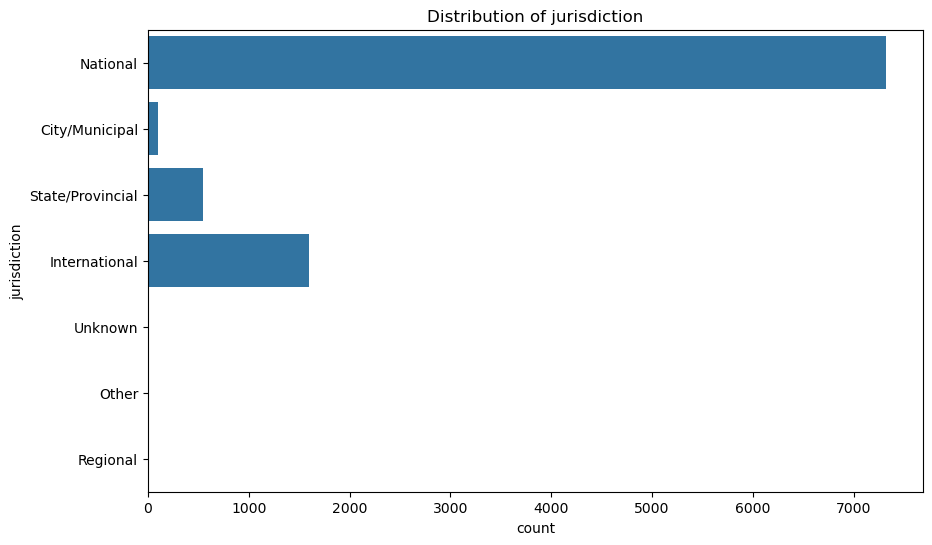

In [29]:
# Plot distribution of jurisdiction
plt.figure(figsize=(10, 6))
sns.countplot(data=IEA_policies_df, y='jurisdiction')
plt.title('Distribution of jurisdiction')
plt.show()

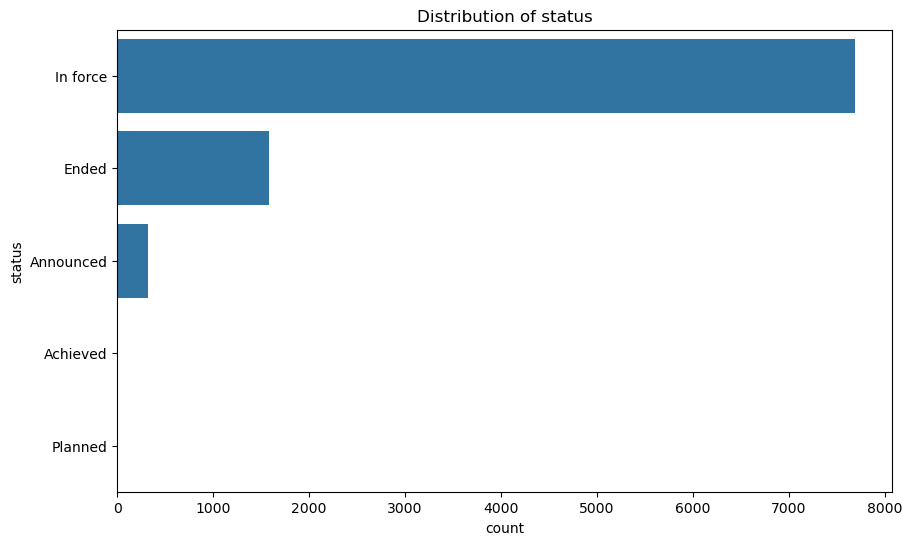

In [30]:
# Plot distribution of status
plt.figure(figsize=(10, 6))
sns.countplot(data=IEA_policies_df, y='status')
plt.title('Distribution of status')
plt.show()


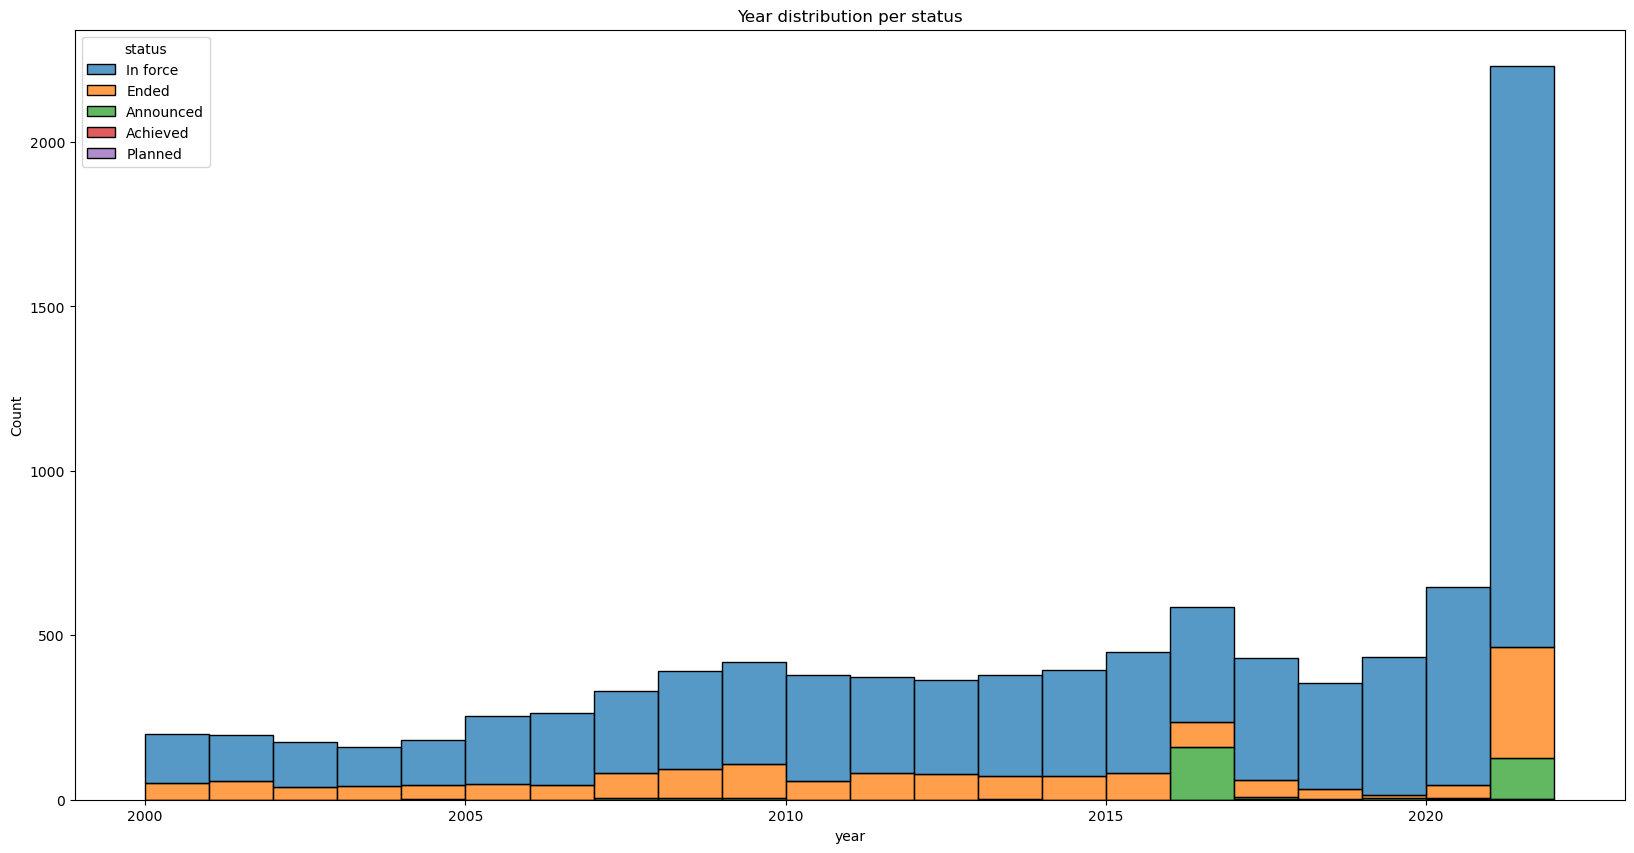

In [31]:
# Plot year distribution per status
plt.figure(figsize=(20, 10))
sns.histplot(data=IEA_policies_df, x='year', hue='status', multiple='stack')
plt.title('Year distribution per status')
plt.show()

In [32]:
# topic	type	category	
print('Amount of types: ', len(IEA_policies_df['type'].unique()))
print('Amount of categories: ',len(IEA_policies_df['category'].unique()))
print('Amount of topics: ', len(IEA_policies_df['topic'].unique()))

Amount of types:  378
Amount of categories:  155
Amount of topics:  64


- **Simple Count/Score:**
For each country and year, count the number of active policies or sum their weighted scores.
    - **Pros:** Simple, transparent.
    - **Cons:** May oversimplify policy heterogeneity.
- **Composite Index:**
Combine multiple dimensions (e.g., type, intensity, status) into a single score using techniques like Principal Component Analysis (PCA) or factor analysis.
    - **Pros:** Captures multiple dimensions in a data-driven way.
    - **Cons:** Interpretation might be more challenging.

## Additional cleaning

In [33]:
# Filter out the policies that have a status of 'Announced', 'Planned'
IEA_policies_df = IEA_policies_df[~IEA_policies_df['status'].isin(['Announced', 'Planned'])]

In [34]:
# Check for repeated values in title column

# Group by title and collect the years for each title
duplicates = IEA_policies_df.groupby('title')['year'].unique().reset_index()

# Filter for titles that appear in more than one year
duplicated_titles = duplicates[duplicates['year'].apply(lambda x: len(x) > 1)]
duplicated_titles.head()

,title,year
775,Bio-energy Infrastructure Scheme,"[2004, 2003]"
816,Biofuels blending mandate,"[2013, 2011]"
890,Building Code of Australia (Non-residential B...,"[2013, 2014]"
892,Building Code of Australia (Multi-Occupancy Bu...,"[2012, 2013, 2014, 2015]"
897,Building Code of Australia (Residential Building),"[2012, 2013, 2014, 2016]"


In [35]:
IEA_policies_df[IEA_policies_df['title'] == 'Energy Efficiency Fund']

,year,jurisdiction,title,description,status,iso3,country,topic,type,category
3627,2010,National,Energy Efficiency Fund,The Energy Efficiency Fund aims to fund the pr...,Ended,LTU,Lithuania,Unknown,Unknown,Unknown
4991,2011,National,Energy Efficiency Fund,"An Energy Efficiency Fund has been set up, con...",Ended,LTU,Lithuania,Unknown,Unknown,Unknown
9050,2012,National,Energy Efficiency Fund,The Energy Efficiency Fund (ESF) is a financia...,In force,PRT,Portugal,Unknown,Unknown,Unknown
9068,2011,National,Energy Efficiency Fund,The fund inlcudes 23 policy measures and provi...,In force,DEU,Germany,Unknown,Unknown,Unknown
11320,2009,National,Energy Efficiency Fund,The Ministry of Economy proposed the Bill on t...,Ended,LTU,Lithuania,Unknown,Unknown,Unknown
11966,2014,National,Energy Efficiency Fund,"The Department of Communications, Climate Acti...",In force,IRL,Ireland,Unknown,Unknown,Unknown


In [36]:
# Group by title and collect the status for each title
duplicates = IEA_policies_df.groupby('title')['status'].unique().reset_index()
duplicates.head()

# NOTE: The same title has the same status. Should we drop the achieved and ended status?

,title,status
0,"\tDecree 12 November 2011, no. 226 (2015 update)",[In force]
1,\tDecree of 16 April 2008,[In force]
2,\tGuidelines for additional environmental meas...,[In force]
3,\tMining Ordinance for the area of coastal wat...,[In force]
4,\tRegulation for the installation of 1 million...,[In force]


In [37]:
print(IEA_policies_df['topic'].unique())

['Unknown' 'Economy-wide' 'Transport' 'Technology R&D and innovation'
 'Methane abatement' 'Transport,Power' 'Power' 'Buildings' 'Industry'
 'Fuels,Power' 'Fuels,Buildings,Industry,Power' 'Just transitions'
 'Transport,Industry,Power' 'Transport,Buildings'
 'Fuels and technology innovation' 'Economy-wide,Methane abatement'
 'Fuels,Industry' 'Industry,Power'
 'People-Centred Clean Energy Transitions' 'Fuels'
 'Fuels and technology innovation,Power' 'Fuels,Transport,Power'
 'Technology R&D and innovation,Power'
 'Technology R&D and innovation,Transport' 'Transport,Buildings,Power'
 'Fuels and technology innovation,Industry' 'Critical Minerals'
 'Buildings,Power' 'Fuels and technology innovation,Buildings'
 'Technology R&D and innovation,Methane abatement'
 'Fuels and technology innovation,Critical Minerals'
 'Just transitions,Fuels,Industry,Power'
 'Fuels and technology innovation,Fuels,Power'
 'Fuels and technology innovation,Fuels,Industry'
 'Fuels and technology innovation,Buildings,I

In [38]:
print(IEA_policies_df['type'].unique())

['Unknown' 'Master Energy Plan,Framework legislation'
 'Fuel efficiency standards,Regulations' 'Grants,Resource push'
 'Networking and sharing,Knowledge management'
 'Reporting requirements,Information,Emissions estimates and quantification,Information'
 'Permitting requirements,Regulations'
 'Government spending for low-emissions and efficient transport,Incentives and investments,Government spending  in storage,Incentives and investments'
 'Loans, grants and other financial incentives,Incentives and investments'
 'Government spending in low-carbon electricity,Incentives and investments'
 'Government spending for low-emissions and efficient transport,Incentives and investments'
 'Government spending for efficient or cleaner technologies,Incentives and investments'
 'Government spending for energy efficiency and recycling,Incentives and investments'
 'Government spending in low-carbon electricity,Incentives and investments,Government spending in hydrogen,Incentives and investments'
 'Go

In [39]:
print(IEA_policies_df['category'].unique())

['Unknown' 'Light-duty vehicles'
 'Grants for demonstration projects,Grants for R&D projects'
 'Connecting innovators and testers,Expert platforms to inform government'
 'Oil and natural gas extraction' 'Light-duty vehicles,Batteries'
 'Solar PVs' '2-/3-wheelers' 'Hydro' 'Existing buildings,Hydro' 'Other'
 'Batteries' 'Aircrafts' 'R&D tax incentives'
 'Emission Trading System (ETS)' 'New buildings' 'Existing buildings'
 'Air conditioners' 'Medium/Heavy-duty vehicles' 'Urban transit'
 'Grants for R&D projects,Grants for R&D projects (co-funded by more than one government)'
 'Grants for R&D projects'
 'Disclosure rules in funding agreements,Grants for demonstration projects'
 'Investment in third party equity fund for start-ups' 'Ships' 'Biogas'
 'Expert platforms to inform government,Technology R&D roadmaps'
 'Carbon tax' 'Technology R&D roadmaps' 'Nuclear'
 'Advanced biofuels,Other' 'Buses,Urban transit' 'Ships,Hydro'
 'Wind turbines' 'Nuclear,Grants for R&D projects'
 'Light-duty vehi

### Plot Policies versus emissions

In [40]:
emissions_db = pd.read_csv(os.path.join(emissions_data_dir_path, 'CSC-GHG_emissions-April2024_to_calibrate.csv'), encoding='latin1')
emissions_db.head()

,Code,Country,EDGAR Country Code,Income group,Lending category,Region,CSC Sector,CSC Subsector,Gas,Units,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
0,ABW,Aruba,ABW,High income,NaN,Latin America & Caribbean,Energy,EN - Building,CH4,MtCO2e,...,0.000554,0.000538,0.000500,0.000570,0.000542,0.000574,0.000471,0.000616,0.000617,0.000622
1,ABW,Aruba,ABW,High income,NaN,Latin America & Caribbean,Energy,EN - Building,CO2,MtCO2e,...,0.047090,0.037332,0.035079,0.039403,0.035488,0.044616,0.050051,0.044068,0.042466,0.044068
2,ABW,Aruba,ABW,High income,NaN,Latin America & Caribbean,Energy,EN - Building,N2O,MtCO2e,...,0.000160,0.000138,0.000130,0.000137,0.000135,0.000235,0.000264,0.000240,0.000234,0.000241
3,ABW,Aruba,ABW,High income,NaN,Latin America & Caribbean,Energy,EN - Electricity/Heat,CH4,MtCO2e,...,0.000114,0.000120,0.000126,0.000127,0.000122,0.000132,0.000156,0.000135,0.000132,0.000136
4,ABW,Aruba,ABW,High income,NaN,Latin America & Caribbean,Energy,EN - Electricity/Heat,CO2,MtCO2e,...,0.213816,0.222204,0.229352,0.239740,0.223555,0.232325,0.274290,0.232537,0.224081,0.232537


In [41]:
# Create a df with the total emissions per year by summing all float cols through axis=0
emission_totals = emissions_db.select_dtypes(include=[np.number]).sum(axis=0).reset_index()
emission_totals.columns = ['year', 'emission_total']
emission_totals['year'] = emission_totals['year'].astype(int)
emission_totals

,year,emission_total
0,2000,35749.969052
1,2001,35366.076858
2,2002,36351.340819
3,2003,38685.869626
4,2004,40922.501207
5,2005,41308.170804
6,2006,42804.911168
7,2007,42978.245611
8,2008,43156.258982
9,2009,42388.952207


In [42]:
emission_totals.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   year            23 non-null     int64  
 1   emission_total  23 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 500.0 bytes


In [43]:
# Create a df with the number of policies per year
policies_per_year = IEA_policies_df['year'].value_counts().reset_index()
policies_per_year.columns = ['year', 'policy_count']
policies_per_year.sort_values('year', inplace=True)
policies_per_year.reset_index(drop=True, inplace=True)

# Calculate the cumulative sum of policies
policies_per_year['accumulated_policy_count'] = policies_per_year['policy_count'].cumsum()
policies_per_year

,year,policy_count,accumulated_policy_count
0,2000,199,199
1,2001,196,395
2,2002,176,571
3,2003,160,731
4,2004,180,911
5,2005,254,1165
6,2006,265,1430
7,2007,327,1757
8,2008,387,2144
9,2009,413,2557


In [44]:
policies_per_year.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   year                      23 non-null     int64
 1   policy_count              23 non-null     int64
 2   accumulated_policy_count  23 non-null     int64
dtypes: int64(3)
memory usage: 684.0 bytes


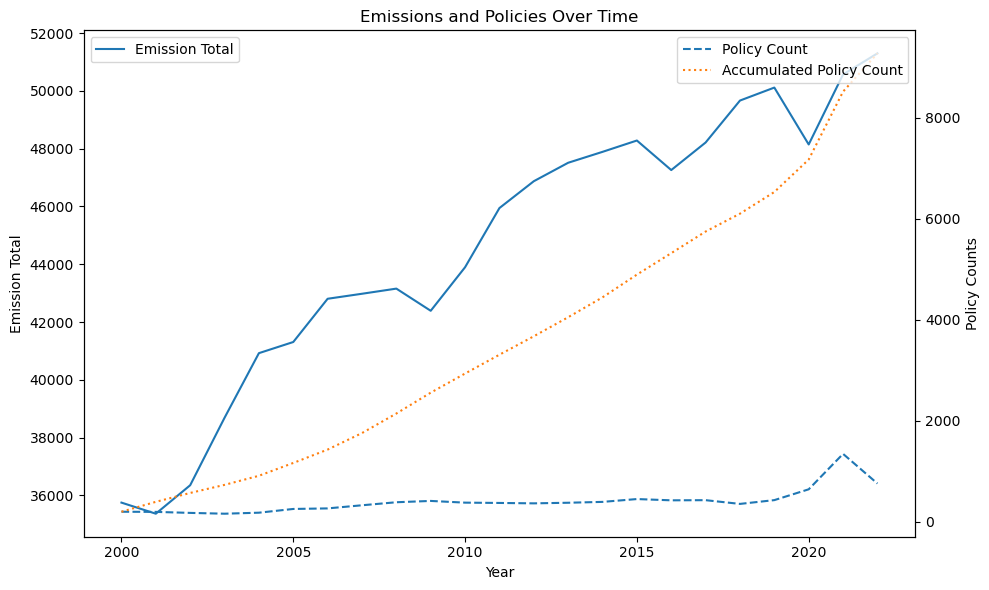

In [45]:
# Assume your dataframes are named emission_totals and policies_per_year

fig, ax1 = plt.subplots(figsize=(10, 6))

# First plot (left y-axis)
ax1.plot(emission_totals['year'], emission_totals['emission_total'], label='Emission Total')
ax1.set_xlabel('Year')
ax1.set_ylabel('Emission Total')

# Create a second y-axis
ax2 = ax1.twinx()

# Second plot (right y-axis) – you can plot both the policy_count and accumulated_policy_count here 
# if you want them on the same scale or separate lines
ax2.plot(policies_per_year['year'], policies_per_year['policy_count'], label='Policy Count', linestyle='--')
ax2.plot(policies_per_year['year'], policies_per_year['accumulated_policy_count'], label='Accumulated Policy Count', linestyle=':')
ax2.set_ylabel('Policy Counts')

# Add a title, manage legends
plt.title('Emissions and Policies Over Time')

# Show legends – one for each axis
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

## Which countries have the largest emissions and the most policies? 

In [47]:
emissions_db = emissions_db.drop(columns=['Country', 'EDGAR Country Code', 'Income group', 'Lending category', 'Region', 'CSC Sector', 'Units'])
emissions_db.head()

,Code,CSC Subsector,Gas,2000,2001,2002,2003,2004,2005,2006,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
0,ABW,EN - Building,CH4,0.000202,0.000214,0.000218,0.000244,0.000263,0.000242,0.000218,...,0.000554,0.000538,0.000500,0.000570,0.000542,0.000574,0.000471,0.000616,0.000617,0.000622
1,ABW,EN - Building,CO2,0.021251,0.023579,0.023320,0.027214,0.032069,0.026398,0.019531,...,0.047090,0.037332,0.035079,0.039403,0.035488,0.044616,0.050051,0.044068,0.042466,0.044068
2,ABW,EN - Building,N2O,0.000218,0.000221,0.000195,0.000211,0.000249,0.000283,0.000234,...,0.000160,0.000138,0.000130,0.000137,0.000135,0.000235,0.000264,0.000240,0.000234,0.000241
3,ABW,EN - Electricity/Heat,CH4,0.000073,0.000075,0.000079,0.000091,0.000095,0.000101,0.000111,...,0.000114,0.000120,0.000126,0.000127,0.000122,0.000132,0.000156,0.000135,0.000132,0.000136
4,ABW,EN - Electricity/Heat,CO2,0.131217,0.133759,0.137867,0.166334,0.171255,0.196176,0.215872,...,0.213816,0.222204,0.229352,0.239740,0.223555,0.232325,0.274290,0.232537,0.224081,0.232537


In [51]:
emissions_db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6624 entries, 0 to 6623
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Code           6624 non-null   object 
 1   CSC Subsector  6624 non-null   object 
 2   Gas            6624 non-null   object 
 3   2000           6583 non-null   float64
 4   2001           6583 non-null   float64
 5   2002           6583 non-null   float64
 6   2003           6583 non-null   float64
 7   2004           6583 non-null   float64
 8   2005           6583 non-null   float64
 9   2006           6583 non-null   float64
 10  2007           6583 non-null   float64
 11  2008           6583 non-null   float64
 12  2009           6583 non-null   float64
 13  2010           6583 non-null   float64
 14  2011           6583 non-null   float64
 15  2012           6583 non-null   float64
 16  2013           6583 non-null   float64
 17  2014           6583 non-null   float64
 18  2015    

In [48]:
# Convert from wide to long format
emissions_db_long = pd.melt(emissions_db, id_vars=['Code', 'CSC Subsector', 'Gas'], var_name='year', value_name='emission')
emissions_db_long.head()

,Code,CSC Subsector,Gas,year,emission
0,ABW,EN - Building,CH4,2000,0.000202
1,ABW,EN - Building,CO2,2000,0.021251
2,ABW,EN - Building,N2O,2000,0.000218
3,ABW,EN - Electricity/Heat,CH4,2000,0.000073
4,ABW,EN - Electricity/Heat,CO2,2000,0.131217


In [59]:
# Create an emission totals by country df
emission_totals_by_country = emissions_db_long.groupby('Code')['emission'].sum().reset_index()
emission_totals_by_country.columns = ['iso3', 'emission_total']
emission_totals_by_country.sort_values('emission_total', ascending=False).head(30)

,iso3,emission_total
38,CHN,236778.089634
216,USA,131670.557581
94,IND,60827.594175
29,BRA,43947.371167
173,RUS,38629.967314
93,IDN,33304.486768
103,JPN,29024.128055
52,DEU,20931.407803
96,IRN,18574.829625
35,CAN,16701.106954


In [57]:
policies_per_country_df.head(10)

,country,policy_count
0,United States,624
1,Australia,383
2,Canada,371
3,People's Republic of China,349
4,United Kingdom,312
5,European Union,283
6,India,274
7,Spain,263
8,Germany,240
9,Mexico,198


In [101]:
# Create a df where we group by iso3 and we count the number of policies per year
policies_per_country_year = IEA_policies_df.groupby(['iso3', 'year'])['title'].count().reset_index()
policies_per_country_year.columns = ['iso3', 'year', 'policy_count']
policies_per_country_year.sort_values(['iso3', 'year'], inplace=True)
policies_per_country_year

,iso3,year,policy_count
0,AFG,2006,1
1,AFG,2019,1
2,AFG,2021,1
3,AGO,2000,2
4,AGO,2004,1
...,...,...,...
2242,ZWE,2012,1
2243,ZWE,2013,1
2244,ZWE,2017,1
2245,ZWE,2019,1


In [103]:
# Compute the cumulative sum per country
policies_per_country_year['cumsum_policy'] = policies_per_country_year.groupby('iso3')['policy_count'].cumsum()
policies_per_country_year

,iso3,year,policy_count,cumsum_policy
0,AFG,2006,1,1
1,AFG,2019,1,2
2,AFG,2021,1,3
3,AGO,2000,2,2
4,AGO,2004,1,3
...,...,...,...,...
2242,ZWE,2012,1,8
2243,ZWE,2013,1,9
2244,ZWE,2017,1,10
2245,ZWE,2019,1,11


## Plot the trajectories of the top countries

In [106]:
def get_target_region_policy_report(policies_per_country_year_df, iso_alpha_3):

    # Filter the df by the iso_alpha_3
    target_region_df = policies_per_country_year_df[policies_per_country_year_df['iso3'] == iso_alpha_3]

    return target_region_df

def get_emissions_by_region_report(emissions_db_long, iso_alpha_3):

    # Filter the df by the iso_alpha_3
    target_region_df = emissions_db_long[emissions_db_long['Code'] == iso_alpha_3]

    # Group by subsector
    target_region_df = target_region_df.groupby(['Code', 'year'])['emission'].sum().reset_index()

    # Sort the df by year
    target_region_df = target_region_df.sort_values('year')

    # reset the index
    target_region_df.reset_index(drop=True, inplace=True)

    return target_region_df

def plot_emission_policy_trajectory(iso_alpha_3, policies_per_country_year_df, emissions_db_long):

    # Make sure the year column is an integer
    policies_per_country_year_df['year'] = policies_per_country_year_df['year'].astype(int)
    emissions_db_long['year'] = emissions_db_long['year'].astype(int)

    # Get the target region policy report
    target_region_policy_report = get_target_region_policy_report(policies_per_country_year_df, iso_alpha_3)

    # Get the emissions by region report
    emissions_by_region_report = get_emissions_by_region_report(emissions_db_long, iso_alpha_3)

    # Create a figure
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # First plot (left y-axis)
    ax1.plot(emissions_by_region_report['year'], emissions_by_region_report['emission'], label='Emission Total')
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Emission Total')

    # Create a second y-axis
    ax2 = ax1.twinx()

    # Second plot (right y-axis) – you can plot both the policy_count and cumsum_policy here 
    # if you want them on the same scale or separate lines
    ax2.plot(target_region_policy_report['year'], target_region_policy_report['policy_count'], label='Policy Count', linestyle='--')
    ax2.plot(target_region_policy_report['year'], target_region_policy_report['cumsum_policy'], label='Accumulated Policy Count', linestyle=':')
    ax2.set_ylabel('Policy Counts')

    # Add a title, manage legends
    plt.title(f'{iso_alpha_3} Emissions and Policies Over Time')

    # Show legends – one for each axis
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

    

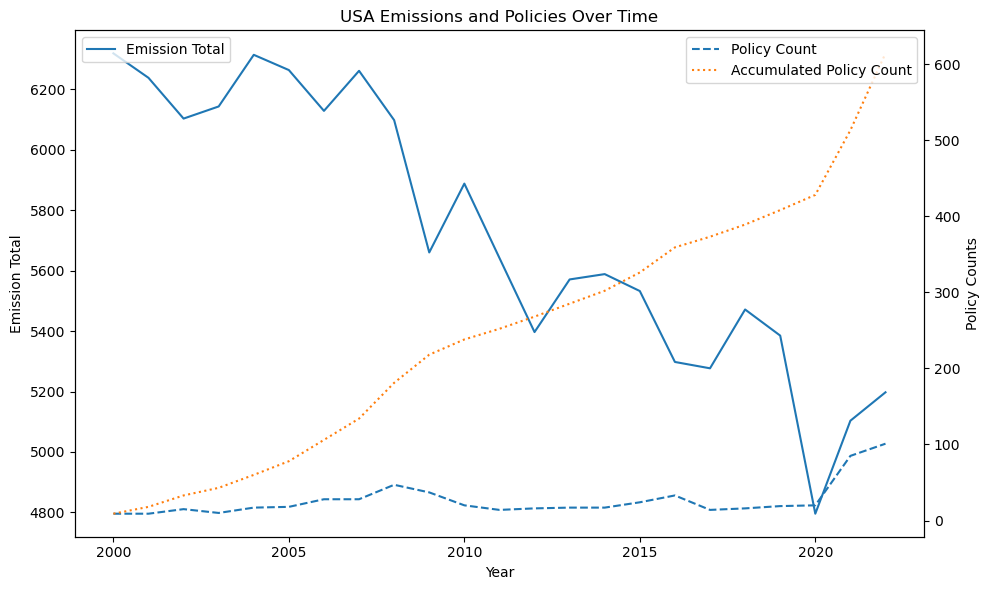

In [107]:
plot_emission_policy_trajectory('USA', policies_per_country_year, emissions_db_long)

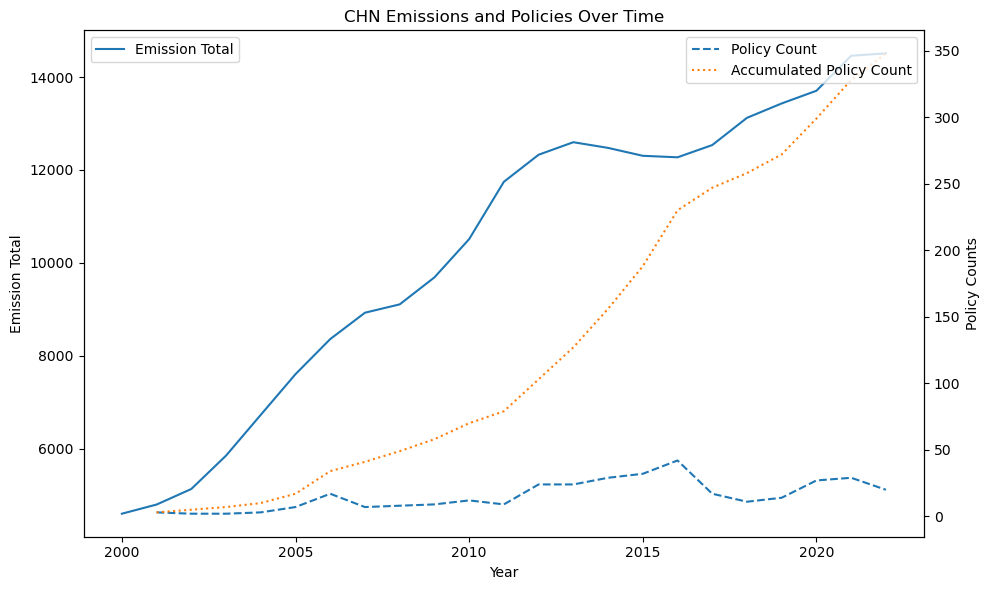

In [108]:
plot_emission_policy_trajectory('CHN', policies_per_country_year, emissions_db_long)

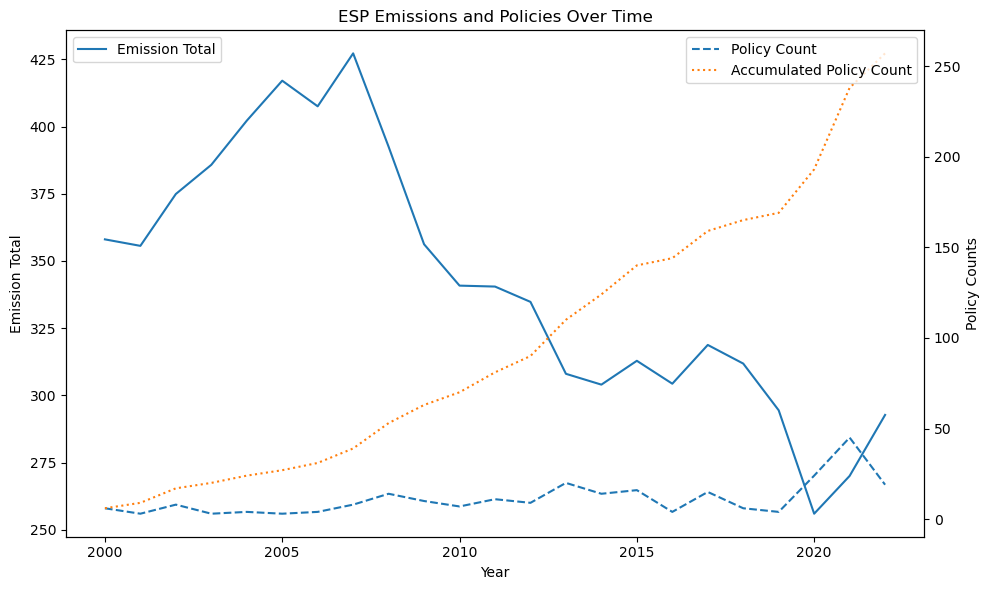

In [109]:
plot_emission_policy_trajectory('ESP', policies_per_country_year, emissions_db_long)

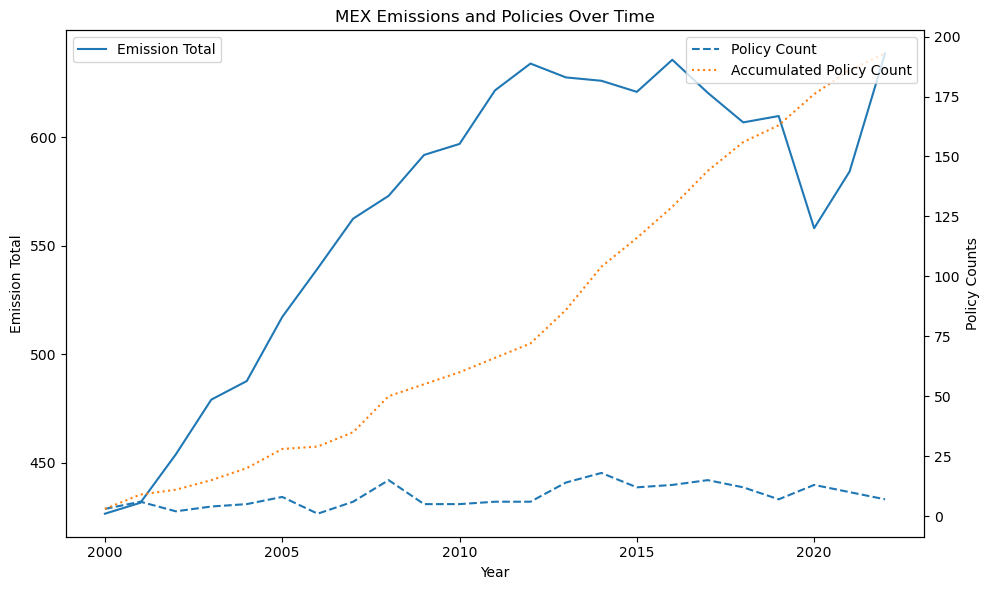

In [110]:
plot_emission_policy_trajectory('MEX', policies_per_country_year, emissions_db_long)

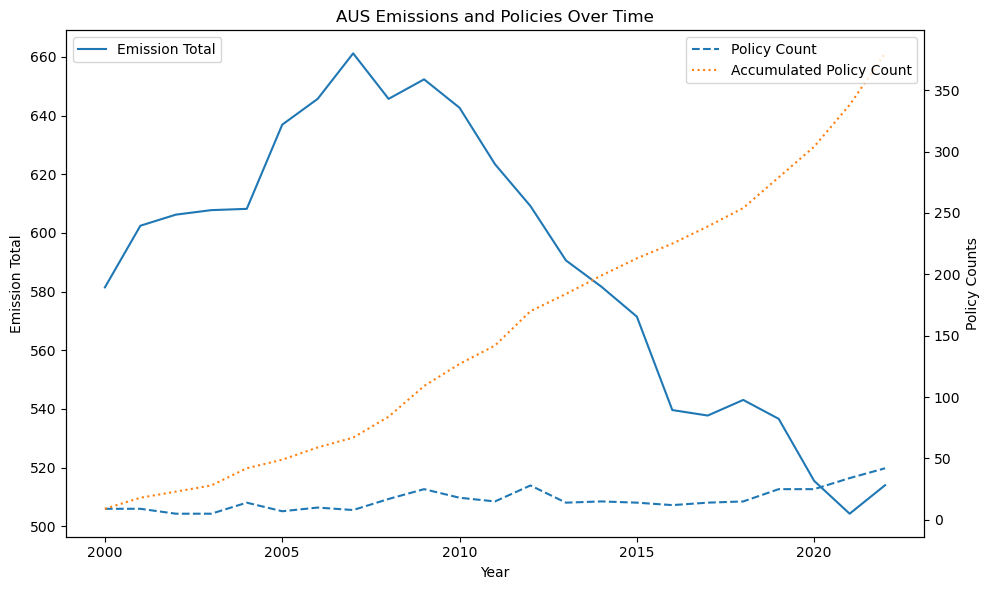

In [111]:
plot_emission_policy_trajectory('AUS', policies_per_country_year, emissions_db_long)

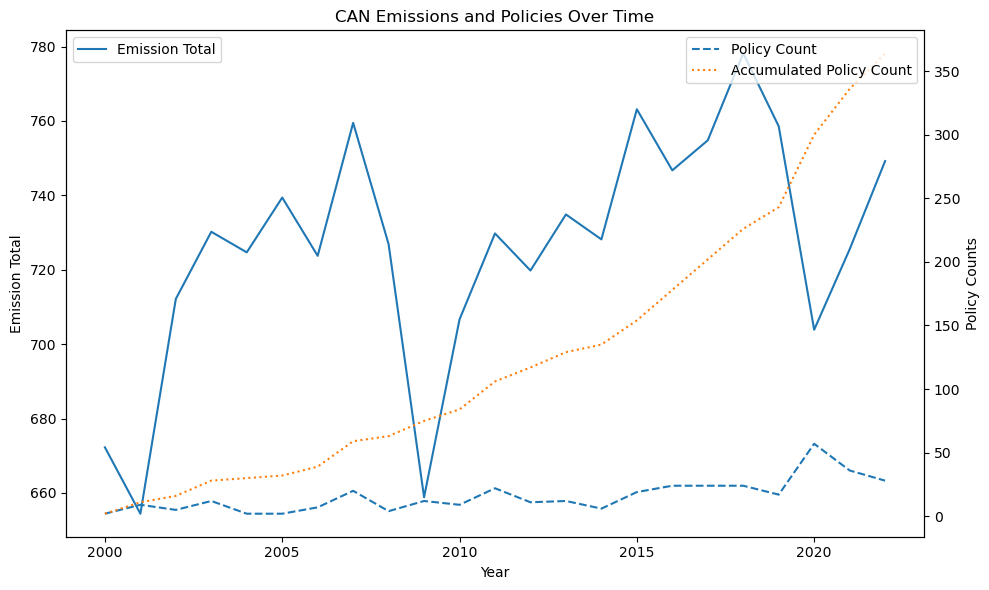

In [112]:
plot_emission_policy_trajectory('CAN', policies_per_country_year, emissions_db_long)

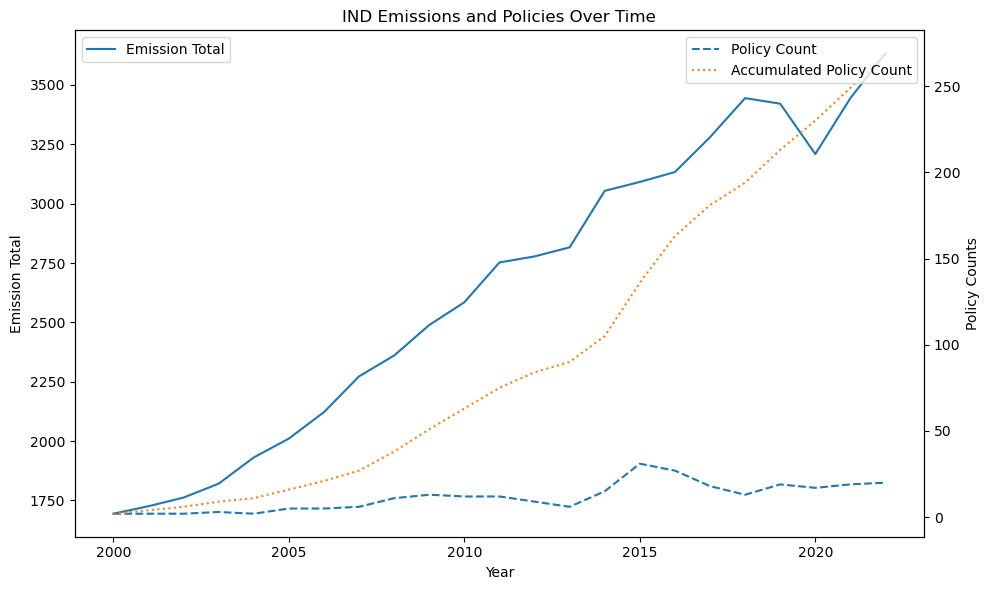

In [113]:
plot_emission_policy_trajectory('IND', policies_per_country_year, emissions_db_long)

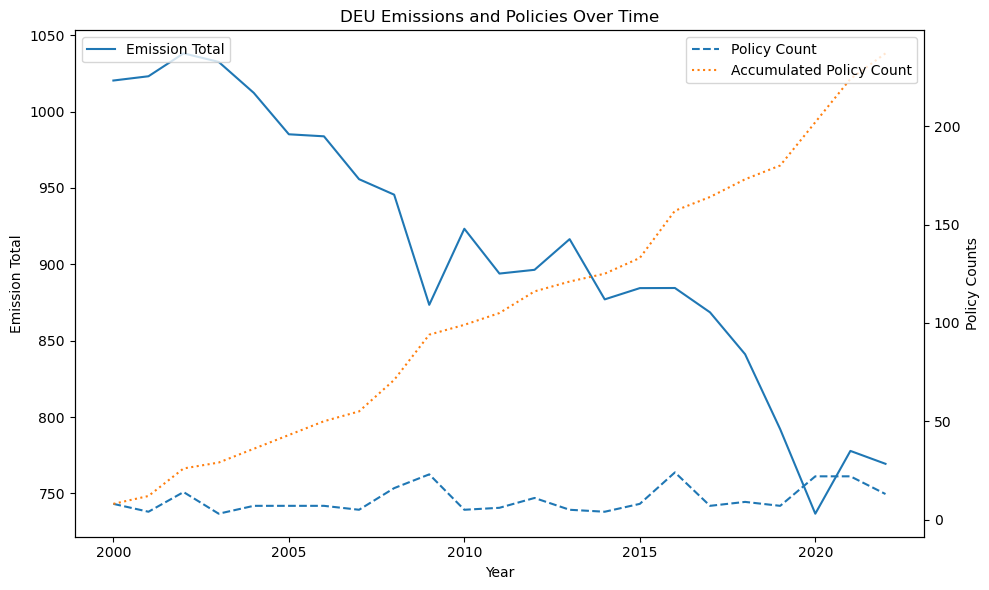

In [114]:
plot_emission_policy_trajectory('DEU', policies_per_country_year, emissions_db_long)

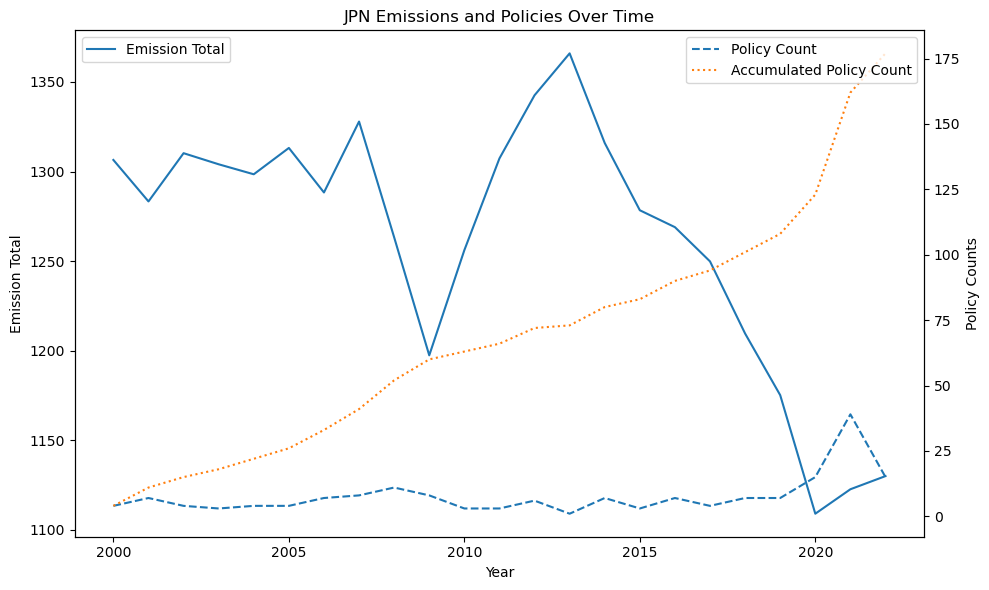

In [115]:
plot_emission_policy_trajectory('JPN', policies_per_country_year, emissions_db_long)

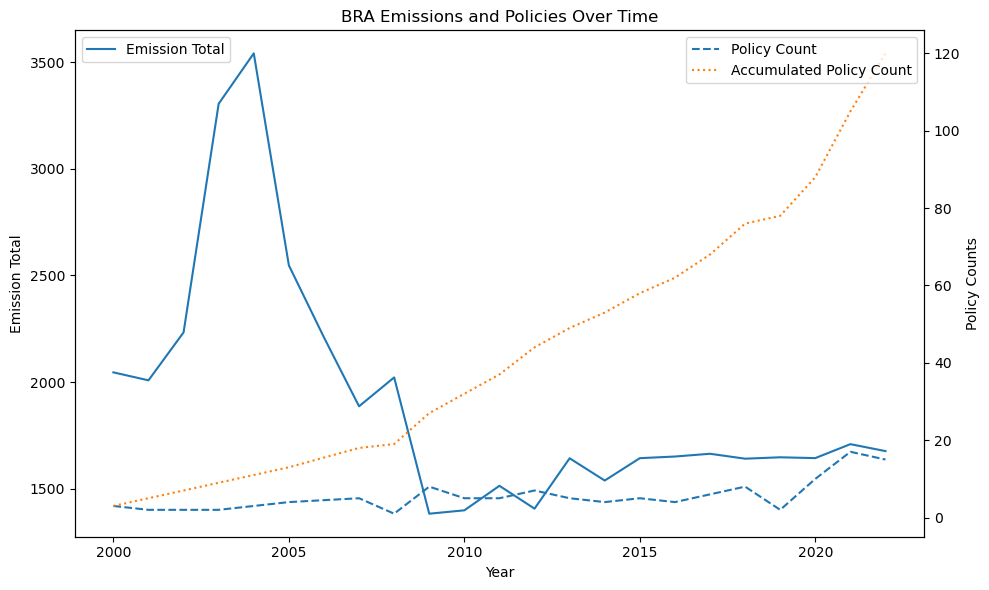

In [116]:
plot_emission_policy_trajectory('BRA', policies_per_country_year, emissions_db_long)